# Redes aleatorias Notas
(Nota: los ejercicios estan mas abajo)

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random

In [2]:
def grafo_erdos_renyi(N,p):
    G = nx.Graph()
    G.add_nodes_from(range(N))
    #agregar aristas con probabilidad
    for i in range(N):
        for j in range(i+1, N):
            if random.random() < p:
                G.add_edge(i, j)
    return G

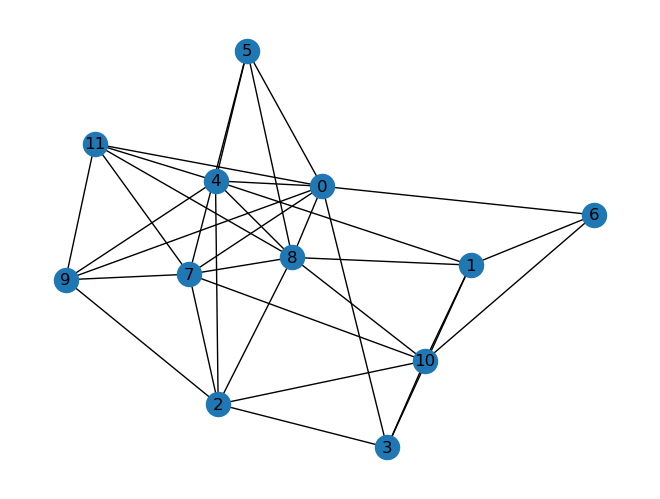

In [3]:
G=grafo_erdos_renyi(12,0.5)
pos = nx.spring_layout(G, seed = 42)

nx.draw(G, pos = pos, with_labels = True)

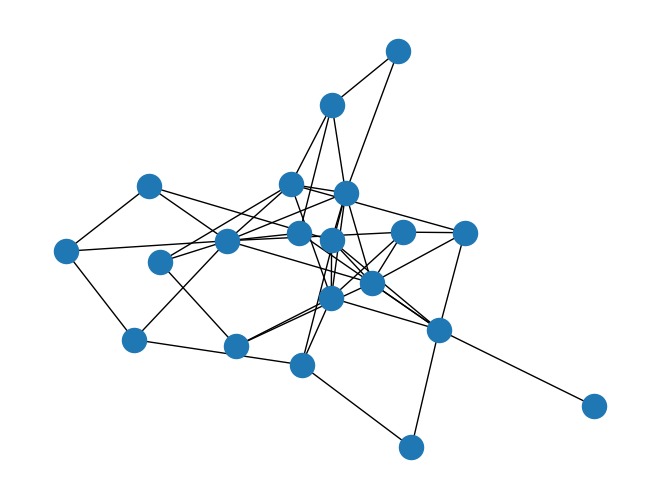

In [4]:
N = 20
p = 0.2
G = nx.erdos_renyi_graph(N,p)
nx.draw(G)

In [5]:
# Distribucion de grado

In [6]:
from scipy.stats import binom, poisson
import numpy as np

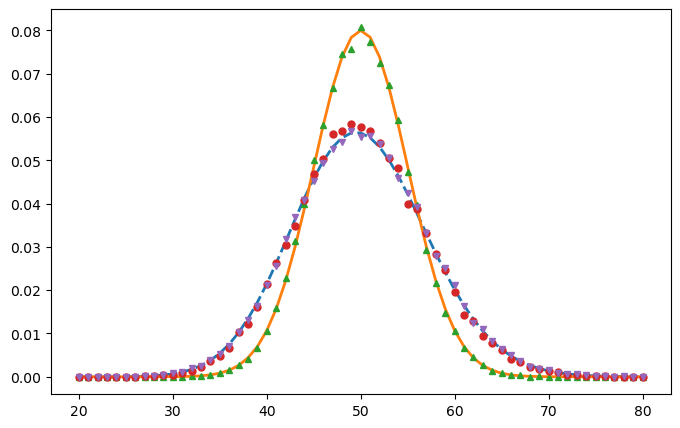

In [7]:
# Parametros

#Grado medio
k_mean = 50

#Valores de N
Ns = [10**2,1000,10000]

#Rando ge k para graficar
k_vals = np.arange(20,81)

plt.figure(figsize = (8,5))

#1: curva poisson teorica
poisson_pmf = poisson.pmf(k_vals, mu = k_mean)
plt.plot(k_vals, poisson_pmf, '--', lw = 2, label= 'Poisson' )


#2: Curva binomial teorica
#Para compara usamos N grande
N_ref = 10**2
p_ref = k_mean/(N_ref-1)
binom_pmf= binom.pmf(k_vals, N_ref-1, p_ref)
plt.plot(k_vals, binom_pmf, '-', lw = 2, label = 'Binomial')

#Datos para distintos N
markers = ['^', 'o','v']
for N, marker in zip(Ns, markers):
    p = k_mean / (N-1)
    #Muestreamos grados directamente de una Binom(N-1, p)
    grados = np.random.binomial(N-1, p, size = 50000)
    #Histograma normalizado
    probs = np.array([(grados == k).mean() for k in k_vals])
    plt.plot(k_vals, probs,linestyle = 'None', marker = marker, markersize = 5)




In [8]:
# Distribucion de numero aristas


In [9]:
def grafo_erdos_renyi(N,p,seed = None): 
    if seed is not None:
        random.seed(seed)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    for i in range(N):
        for j in range(i+1, N):
            if random.random() < p:
                G.add_edge(i,j)
    return G

In [10]:
def dibujar_realizaciones(N, p, n_realizaciones=3, layout = 'spring', seed_base = 10):
    fig, axes = plt.subplots(1, n_realizaciones, figsize = (5*n_realizaciones, 5))
    if n_realizaciones == 1:
        axes = [axes]
    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N,p, seed = seed_base + k)
        #elegir layout
        if layout == 'circular':
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed = seed_base+k)
        L = G.number_of_edges()
        nx.draw_networkx_nodes(G, pos, ax = ax, node_size = 300, node_color = '#7a4fa3')
        nx.draw_networkx_edges(G, pos, ax = ax, edge_color = 'limegreen', width = 1.5)
        ax.set_title(f'realizacion {k+1} \n N={N}, L ={L}, fontsize = 12')
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

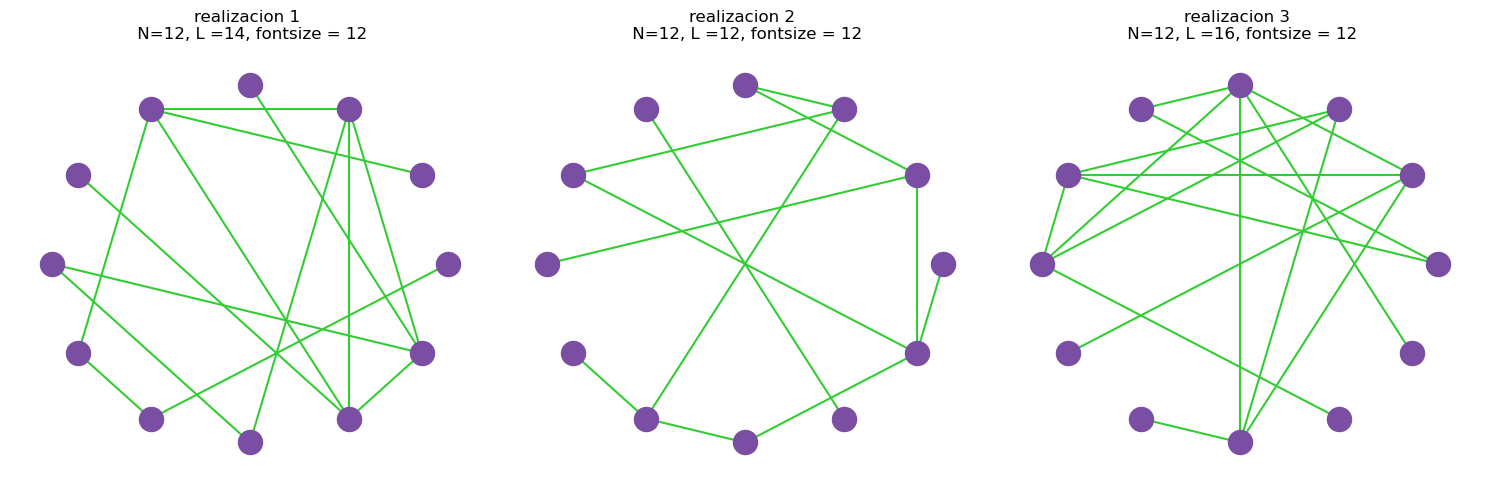

In [11]:
dibujar_realizaciones(N=12,p = 1/6, n_realizaciones = 3, layout = 'circular')



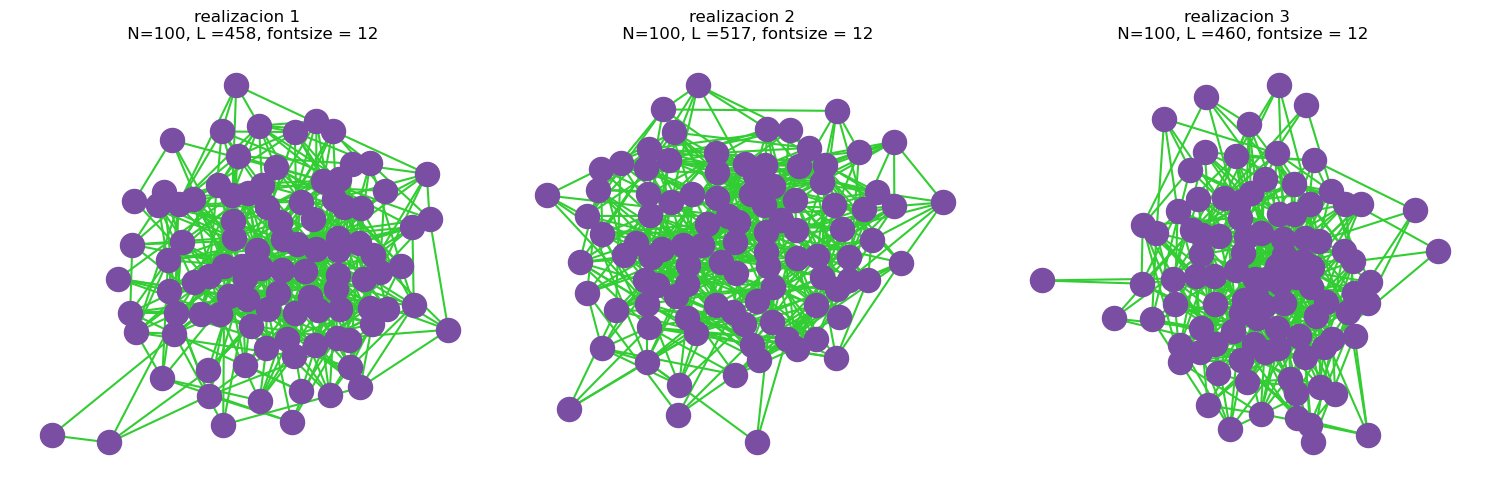

In [12]:
dibujar_realizaciones(N=100, p =0.1, n_realizaciones = 3, layout = 'spring')

In [13]:
def dibujar_realizaciones_con_esperanza(N, p, n_realizaciones=3, layout = 'spring', seed_base = 10):
    fig, axes = plt.subplots(1, n_realizaciones, figsize = (5*n_realizaciones, 5))
    if n_realizaciones == 1:
        axes = [axes]

    L_esperado = (p* N* (N-1))/2
        
    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N,p, seed = seed_base + k)
        #elegir layout
        if layout == 'circular':
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed = seed_base+k)
        L = G.number_of_edges()
        nx.draw_networkx_nodes(G, pos, ax = ax, node_size = 300, node_color = '#7a4fa3')
        nx.draw_networkx_edges(G, pos, ax = ax, edge_color = 'limegreen', width = 1.5)
        ax.set_title(f'realizacion {k+1} \n N={N}, L ={L}, fontsize = 12,\n L_esperado = {L_esperado}')
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

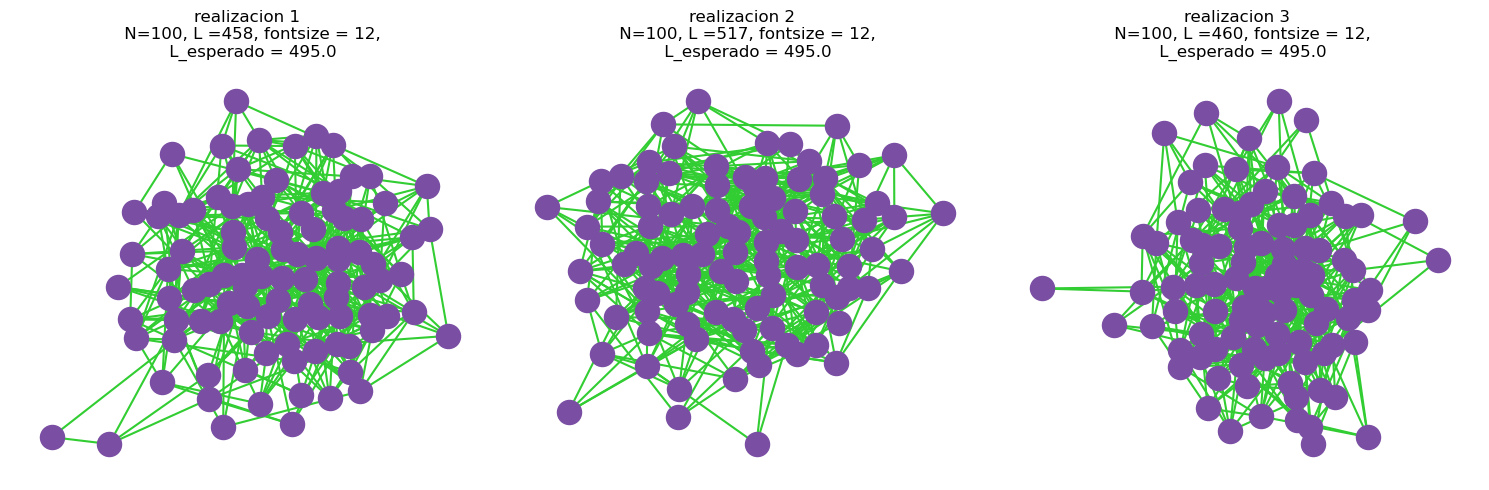

In [14]:
dibujar_realizaciones_con_esperanza(N=100, p =0.1, n_realizaciones = 3, layout = 'spring')

In [15]:
def simular_numero_aristas(N,p , n_sim=1000):
    valores_L = []
    for s in range(n_sim):
        G = grafo_erdos_renyi(N,p, seed=s)
        valores_L.append(G.number_of_edges())
    return valores_L

Text(0.5, 0, 'Numero de aristas')

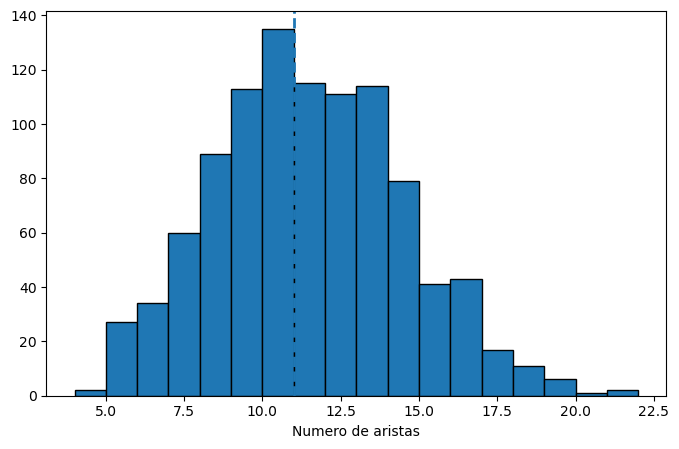

In [16]:
N = 12
p = 1/6
valores_l = simular_numero_aristas(N,p, n_sim = 1000)

L_esperado = p*N*(N-1)/2
plt.figure(figsize = (8,5))
plt.hist(valores_l, bins = range(min(valores_l), max(valores_l)+2), edgecolor = 'black')
plt.axvline(L_esperado, linestyle = '--', linewidth = 2, label = f'E[L] = {L_esperado}')
plt.xlabel( 'Numero de aristas')

# Ejercicio 3.1.3
Considere un grafo aleatorio  
G(N,p)con  N
=20 y  p=0.2.
Genere una realización del grafo.

Calcule el número de aristas observadas  L.

Calcule el número esperado de aristas:

Compare el valor observado con el valor esperado.

Dibuje la red obtenida.

In [17]:
#Compara el valor esperado con el valor real de las aristas
n = 20
p = 0.2
G = nx.erdos_renyi_graph(20, 0.2)
edges = nx.number_of_edges(G)
edges_mean = p * (n)*(n-1)/2

print('aristas:', edges)
print('valor esperado de las aristas', edges_mean)

aristas: 34
valor esperado de las aristas 38.0


¿Por qué el número de aristas observado no tiene por qué coincidir exactamente con  
⟨
L
⟩
 ? Porque el numero de esperanza en aristas no deja solo de ser una posibilidad en una red aleatoria

## Ejercicio 2. Variabilidad del número de aristas

Fije  N=30 y  p=0.1.

Genere 100 realizaciones independientes del grafo aleatorio  
G
(
N
,
p
)
 .
 
Para cada realización, calcule el número de aristas  L.

Construya un histograma de los valores obtenidos.

Calcule el promedio muestral de  L.

Compare este promedio con el valor teórico:

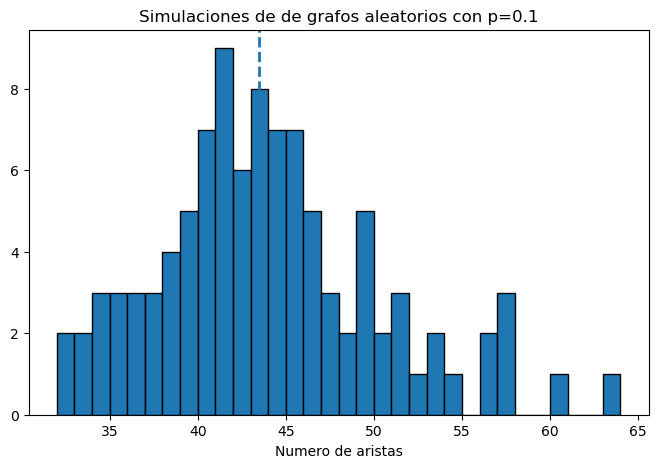

L: 43.54
Valor Teorico: 43.5


In [18]:
#Fijo N y p
N = 30
p = 1/10
valores_l = simular_numero_aristas(N,p, n_sim = 100)

L_esperado = p*N*(N-1)/2
plt.figure(figsize = (8,5))
plt.hist(valores_l, bins = range(min(valores_l), max(valores_l)+2), edgecolor = 'black')
plt.axvline(L_esperado, linestyle = '--', linewidth = 2, label = f'E[L] = {L_esperado}')
plt.xlabel( 'Numero de aristas')
plt.title(f'Simulaciones de de grafos aleatorios con p={p}')
plt.show()
print('L:', np.mean(valores_l))
print('Valor Teorico:', p * N *(N-1)/2)

Explique por qué, aun cuando los parámetros  
N
  y  
p
  son los mismos, distintas realizaciones pueden tener diferente número de aristas.


Respuesta: Porque justamente al seguir una distribucion normal la red aleatoria la media de los datos coincide con la esperanza

## Ejercico 3
Considere un grafo aleatorio  
G(N,p)  con  N =100 y  p=0.05.

Genere una realización del grafo.

Calcule el grado de cada nodo.

Obtenga el grado promedio observado.

Compare con el valor teórico:⟨k⟩=p(N−1).

Verifique numéricamente que ⟨k⟩obs=2L/N, donde  L  es el número de aristas observadas.

In [19]:
G =grafo_erdos_renyi(100,0.05)
degree = nx.degree(G)
grado_prom = 2*nx.number_of_edges(G)/ nx.number_of_nodes(G)
k = 0.05*(100-1)
kobs = 2*nx.number_of_edges(G)/100

In [20]:
print('Grado promedios del grafo:',grado_prom)
print('Grados teorico esperado:',k)

Grado promedios del grafo: 4.64
Grados teorico esperado: 4.95


In [21]:
print('Grado promedio observado:',kobs)

Grado promedio observado: 4.64


¿Por qué el promedio de grados está relacionado con el número de aristas mediante la expresión  
2
L
N
 ?

Respuesta: Porque la formula contiene el numero de aristas

## Ejercicio 4. Distribución de grados

Considere un grafo aleatorio  
G(N,p) con N=100 y  p=0.05 .

Genere una realización del grafo.

Calcule la secuencia de grados.

Haga un histograma de la distribución de grados.

Calcule el grado promedio observado.

Compare visualmente la distribución obtenida con una distribución binomial.

In [22]:
G = nx.erdos_renyi_graph(100,0.05)
deg_list = dict(nx.degree(G)).values()
deg_list = list(deg_list)

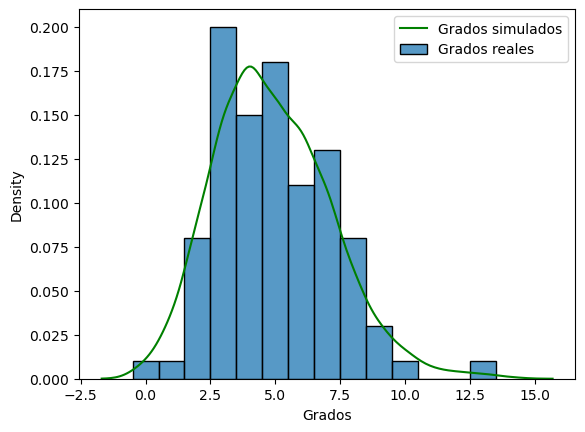

In [23]:
import seaborn as sns
plt.figure()
sns.histplot(deg_list, stat = 'density', discrete = True, label = 'Grados reales')
sns.kdeplot(np.random.binomial(100,0.05,size= 1000),color = 'green', label = 'Grados simulados')
plt.legend()
plt.xlabel('Grados')
plt.show()


In [24]:
grado_prom = 2*nx.number_of_edges(G)/ nx.number_of_nodes(G)
print( 'Grado promedio observado', grado_prom)

Grado promedio observado 4.98


¿Por qué en el modelo de Erdős–Rényi la distribución de grados se modela mediante una distribución binomial? porque en cierta manera modela el numero de exitos (conexiones en un grafo)

## Ejercicio 5. Efecto de la probabilidad de conexión

Fije  N=50 y considere los valores
p=0.01,0.05,0.1,0.2. 

Genere una realización del grafo aleatorio  
G(N,p)  para cada valor de  p.
Para cada grafo, calcule:
el número de aristas  L,

el grado promedio observado,

el número de componentes conexas.

Dibuje las cuatro redes obtenidas.

Organice los resultados en una tabla.

In [25]:
import pandas as pd
#Creo los grados y defino los los grados y el numero de componentes
N = 50
p = [0.01,0.05,0.1,0.2]
G = [nx.erdos_renyi_graph(N,i) for i in p ]
deg = []
cc = []
for g in G:
    m = nx.number_of_edges(g)
    n = nx.number_of_nodes(g)
    cc1 = nx.number_connected_components(g)

    deg.append(2*m/n)
    cc.append(cc1)
data = {'P': p, 'Grados promedio': deg, 'Numero de componentes conexas': cc}
data = pd.DataFrame(data)
print(data)

      P  Grados promedio  Numero de componentes conexas
0  0.01             0.40                             40
1  0.05             3.08                              2
2  0.10             4.60                              2
3  0.20            10.20                              1


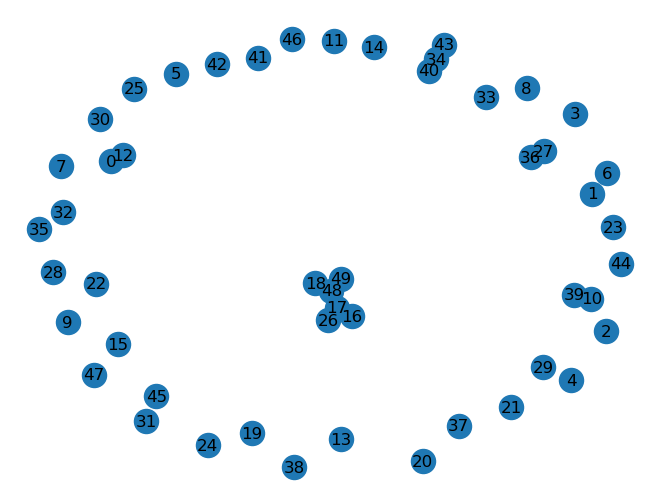

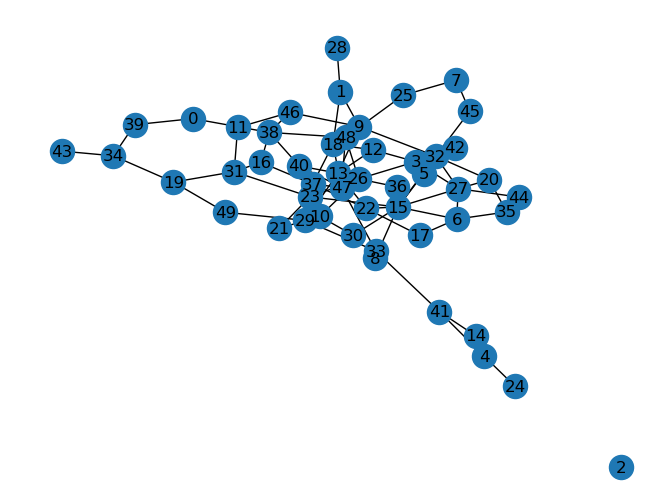

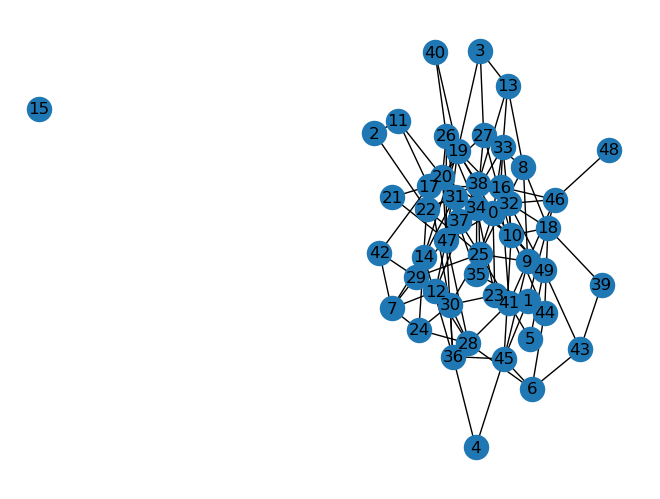

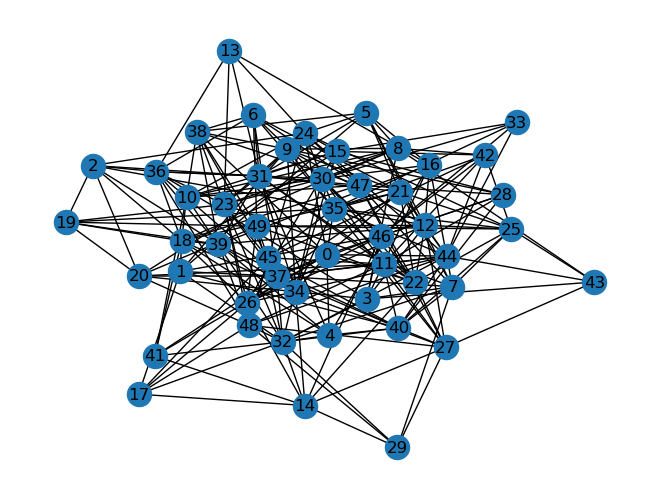

In [26]:
#Graficas de los grafos
for g in G:
    nx.draw(g, with_labels=True)
    plt.show()

Pregunta conceptual.
Describa cómo cambia la estructura de la red al aumentar el valor de  
p
 .


Respuesta: Empieza a aparecer una componente gigante que se va haciendo cada vez mas grande



## Ejercicio 6. Exploración del número de aristas y del grado promedio

Fije  N=100 y considere una colección de valores de  p en el intervalo  [0.01,0.20].

Para cada valor de  p, genere una realización del grafo aleatorio G(N,p).
Calcule para cada caso:

el número de aristas  L,el grado promedio observado.

Grafique el número de aristas observado en función de p.

Grafique el grado promedio observado en función de  p.

Compare los resultados con las expresiones teóricas:

In [27]:
#Creo las graficas y los array de grados promedio y numero de aristas
N = 100
p = np.linspace(0.1,0.2,100)
G = [nx.erdos_renyi_graph(N,i) for i in p ]
m_arr =[]
deg = []
cc = []

L =[]
k = []

i=0
for g in G:
    m = nx.number_of_edges(g)
    n = nx.number_of_nodes(g)
    cc1 = nx.number_connected_components(g)
       
    l1 = p[i]*n*(n-1)/2
    k1 = p[i]*(n-1)

    
    deg.append(2*m/n)
    cc.append(cc1)
    m_arr.append(m)
    k.append(k1)
    L.append(l1)
    i += 1

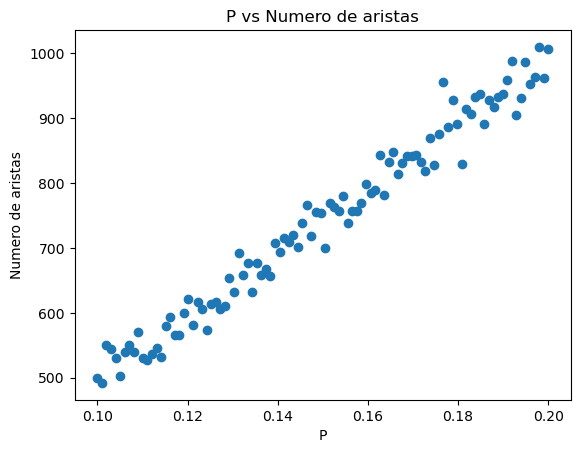

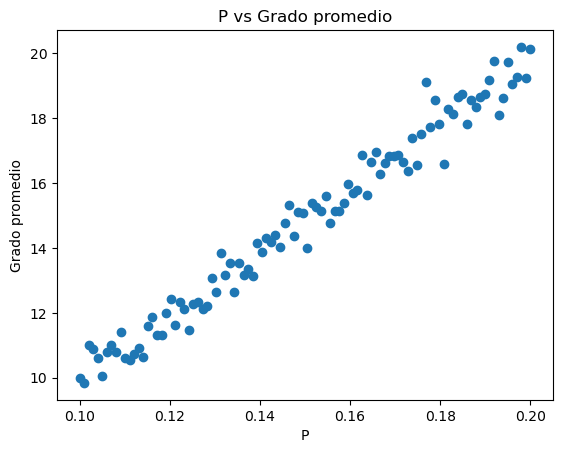

In [28]:
fig = plt.figure()
plt.scatter(p,m_arr)
plt.title('P vs Numero de aristas')
plt.xlabel('P')
plt.ylabel('Numero de aristas')
plt.show()

fig = plt.figure()
plt.scatter(p,deg)

plt.title('P vs Grado promedio')
plt.xlabel('P')
plt.ylabel('Grado promedio')
plt.show()

¿De qué manera dependen el número esperado de aristas y el grado promedio esperado del parámetro  
p
 ?

Respuesta: Depende de forma proporcional por como esta dada la formula.

# 3.1.4 Ejercicios: componente gigante, clustering y regímenes en grafos de Erdős–Rényi

## Ejercicio 1. Componentes conexas al variar la probabilidad de conexión

Fije  N=100 y considere los valores p=0.001,0.005,0.01,0.02,0.03,0.05.

Para cada valor de  p:

Genere una realización del grafo aleatorio  G(N,p).

Calcule el número de componentes conexas.

Calcule el tamaño de la componente conexa más grande.

Dibuje la red obtenida.

Organice los resultados en una tabla.


In [29]:
N=100
p =[0.001,0.005,0.01,0.02,0.03,0.05]

G = [nx.erdos_renyi_graph(N,i) for i in p ]

ncc = []
cc = []


for g in G:
    m = nx.number_of_edges(g)
    n = nx.number_of_nodes(g)
    ncc1 = nx.number_connected_components(g)

    largest_cc = max(nx.connected_components(g), key=len)
    len_lgstcc = len(largest_cc)
    
    ncc.append(ncc1)
    cc.append(len_lgstcc)
data = {'P': p, "# de componentes conexas": ncc, "len de componente conexa mas grande": cc}
data  = pd.DataFrame(data)
print(data)

       P  # de componentes conexas  len de componente conexa mas grande
0  0.001                        99                                    2
1  0.005                        74                                    4
2  0.010                        40                                   25
3  0.020                        16                                   78
4  0.030                         8                                   91
5  0.050                         1                                  100


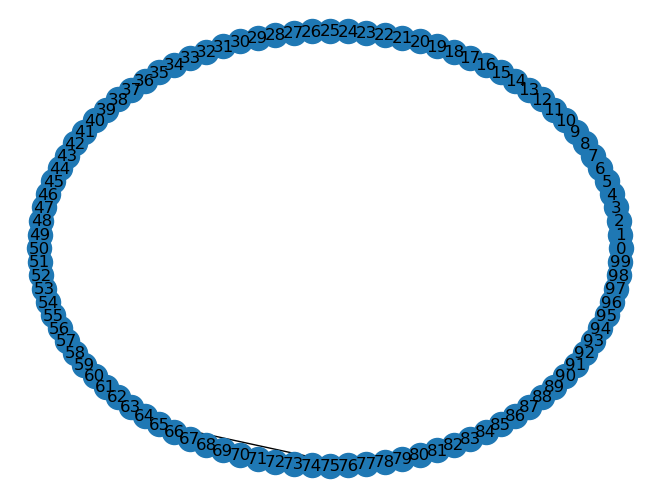

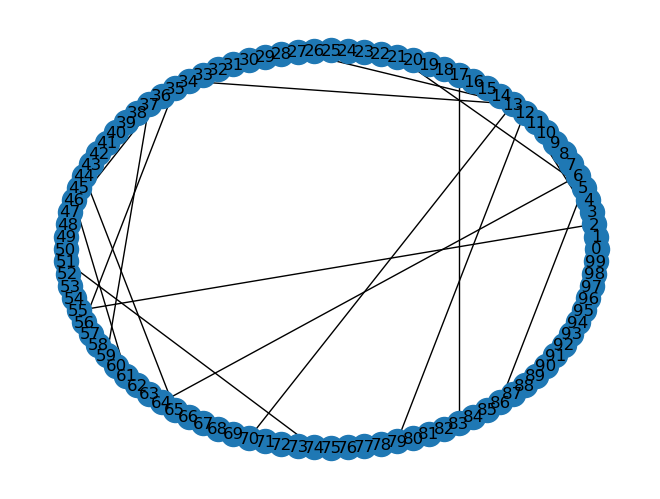

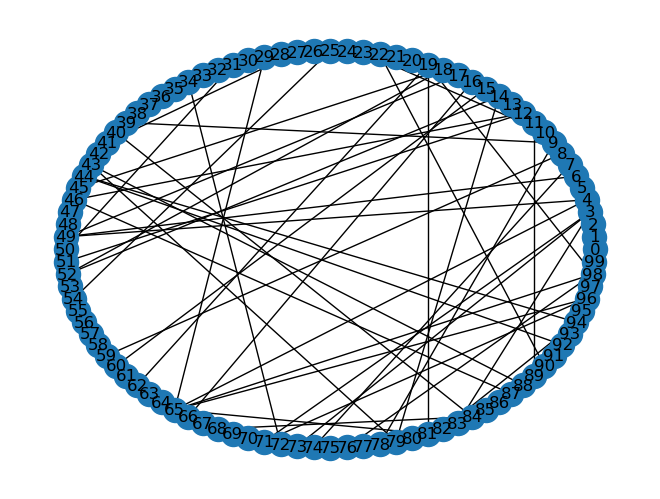

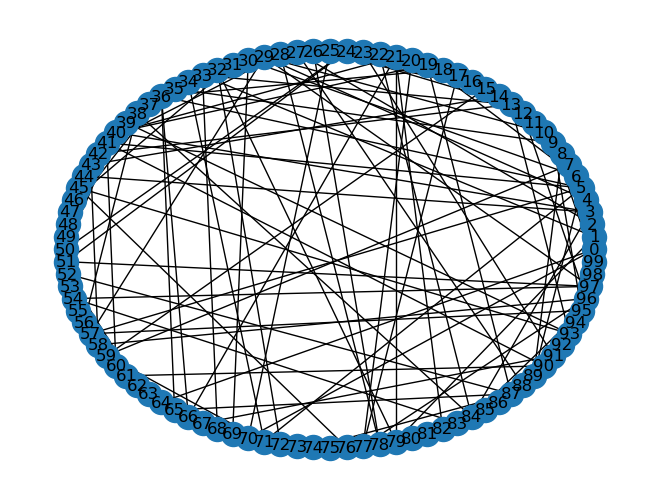

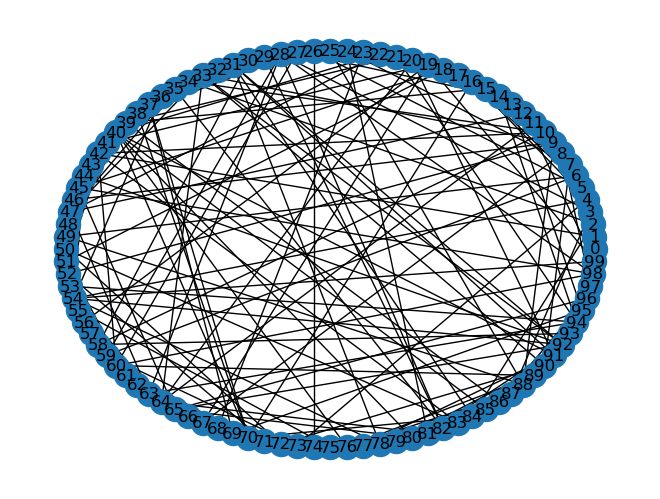

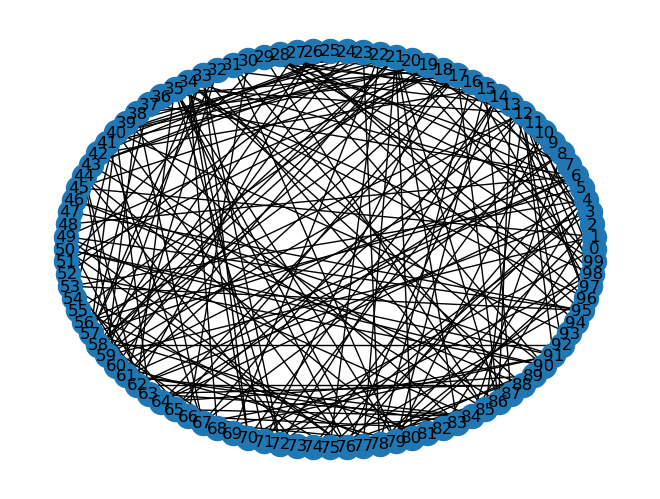

In [30]:
for g in G:
    pos = nx.circular_layout(g)
    nx.draw(g, with_labels=True, pos = pos)
    plt.show()

Pregunta conceptual.
¿Cómo cambia la estructura de la red al aumentar  
p
 ? empieza a parecerce a una red conexa
 
 ¿En qué rango parece emerger una componente gigante? en 0.03

## Ejercicio 2. Tamaño relativo de la componente gigante

Fije  
N=200 y considere valores de  p en el intervalo  [0.001,0.03].

Para cada valor de  p, genere una realización del grafo aleatorio  G(N,p).

Calcule el tamaño de la componente conexa más grande, denotado por  Smax.

Calcule la fracción Smax/N.

Grafique  Smax/N en función de  p.

In [31]:
N =200
p = np.linspace(0.001,0.03,50)
G = [nx.erdos_renyi_graph(N,i) for i in p ]

ncc = []
cc = []
Smax_n = []

for g in G:
    m = nx.number_of_edges(g)
    n = nx.number_of_nodes(g)
    ncc1 = nx.number_connected_components(g)

    largest_cc = max(nx.connected_components(g), key=len)
    len_lgstcc = len(largest_cc)
    smax = len_lgstcc/n
    
    ncc.append(ncc1)
    cc.append(len_lgstcc)
    Smax_n.append(smax)

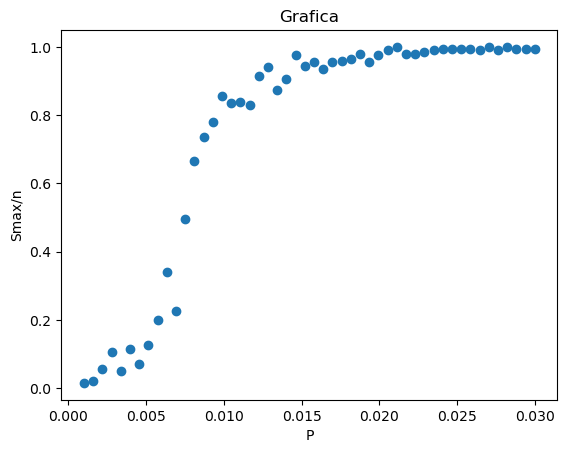

In [32]:
plt.figure()
plt.scatter(p,Smax_n)
plt.title("Grafica")
plt.xlabel('P')
plt.ylabel('Smax/n')
plt.show()


¿En qué rango de valores de  
p
  comienza a crecer rápidamente la componente más grande? a partir de 0.005

## Ejercicio 3. Aparición de la componente gigante y grado promedio

Fije  
N=200y considere los valores p=0.5/N−1,1/N−1,
1.5/N−1,2/N−1,3/N−1.
 

Para cada valor de  p:
Calcule el grado promedio esperado ⟨k⟩=p(N−1).
 
Genere una realización del grafo.

Calcule el tamaño de la componente conexa más grande.
    
Compare los resultados obtenidos.

In [33]:
N = 200
p = 1/N * np.array([0.5,1,1.5,2,3])

G = [nx.erdos_renyi_graph(N,i) for i in p]
k_arr = []
S = []

i = 0
for g in G:
    k = p[i]*(N-1)
    largest_cc = max(nx.connected_components(g), key=len)
    len_lgstcc = len(largest_cc)

    S.append(len_lgstcc)
    k_arr.append(k)
    i+=1

data = {'p': p, 'k' : k_arr, 'S': S}
data = pd.DataFrame(data)
print(data)

        p       k    S
0  0.0025  0.4975    5
1  0.0050  0.9950   61
2  0.0075  1.4925  124
3  0.0100  1.9900  158
4  0.0150  2.9850  192


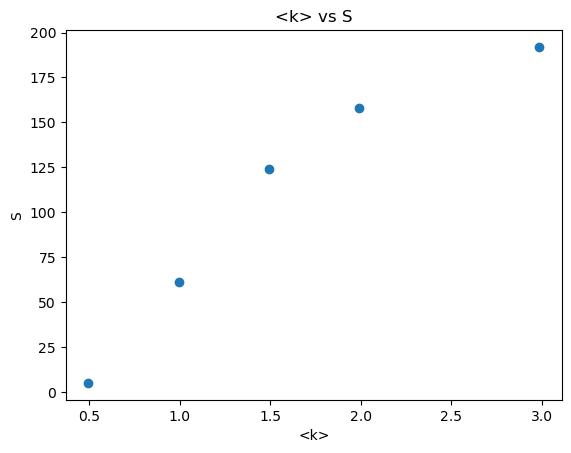

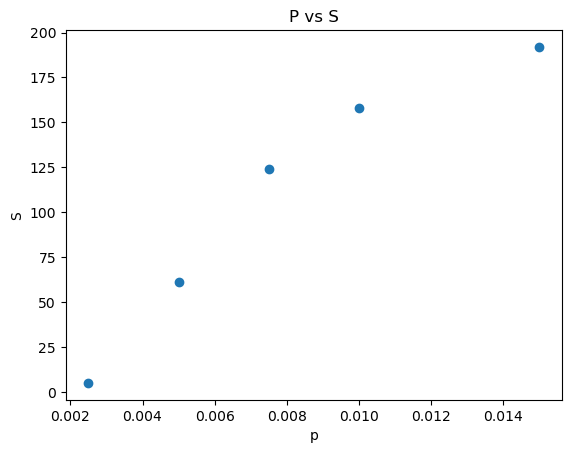

In [34]:
plt.scatter(k_arr,S)
plt.title('<k> vs S')
plt.xlabel('<k>')
plt.ylabel('S')
plt.show()
plt.scatter(p,S)
plt.title('P vs S')
plt.xlabel('p')
plt.ylabel('S')
plt.show()

¿Qué relación observa entre la aparición de una componente gigante y el valor del grado promedio esperado? que el valor promedio esperado empieza a ser mayor a 1

## Ejercicio 4. Coeficiente de clustering en una realización

Considere un grafo aleatorio  G(N,p) con  N=100 y  p=0.05.

Genere una realización del grafo.

Calcule el coeficiente de clustering local de cada nodo.

Calcule el coeficiente de clustering promedio de la red.

Compare el valor observado con el valor teórico esperado


In [35]:
N = 100
p = 0.05
G = nx.erdos_renyi_graph(N,p)
clus_loc = nx.clustering(G)
clus_global = nx.average_clustering(G)
print('Clustering promedio observado:', clus_global)
print('Clustering teorico: ', p)

Clustering promedio observado: 0.05360533910533911
Clustering teorico:  0.05


¿Por qué en el modelo de Erdős–Rényi el coeficiente de clustering esperado es aproximadamente igual a  p?
Respuesta: porque dado un nodo y sus dos vecinos la probabilidad que estos se connecten es igual a p


## Ejercicio 5. Clustering promedio al variar  p
 

Fije  N=100 y considere valores de  p en el intervalo  [0.01,0.20].

Para cada valor de p, genere una realización del grafo aleatorio  G(N,p).
Calcule el coeficiente de clustering promedio observado.
Grafique el clustering promedio observado en función de  p.
Compare con la recta teórica C=p.
 
Pregunta conceptual.
¿Cómo depende el clustering promedio del parámetro  p? parece depender de forma casi lineal

In [36]:
N = 100
p = np.linspace(0.01,0.2,200)

G = [nx.erdos_renyi_graph(N,i) for i in p]
clus = []
prom = []

i = 0
for g in G:
    clus1 = nx.average_clustering(g)
    degprom = 2* nx.number_of_edges(g)/nx.number_of_nodes(g)

    clus.append(clus1)
    prom.append(degprom)
    i+=1

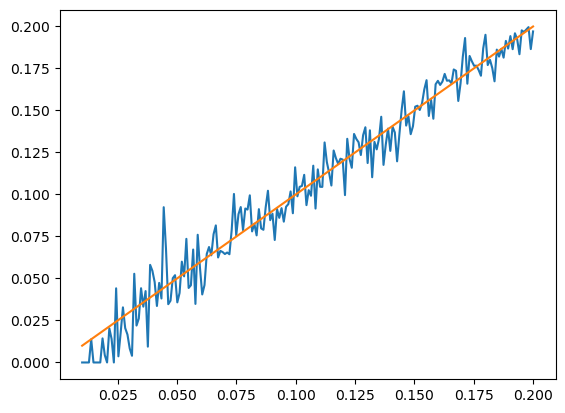

In [37]:
plt.plot(p, clus)
plt.plot(p,p)

## Ejercicio 6. Componente gigante y clustering

Fije  N=200 y considere valores de p en un intervalo que incluya el umbral de aparición de la componente gigante.
Para cada valor de p:

Genere una realización de  G(N,p).

Calcule:
el tamaño relativo de la componente más grande,Smax/N,el coeficiente de clustering promedio  C.
    
Grafique ambas cantidades en función de  p.

Pregunta conceptual.
¿Qué diferencia hay entre una propiedad global, como el tamaño de la componente gigante, y una propiedad local, como el clustering? la diferencia radica en la que con la propiedad local parece tener una relacion mas o menos lineal y con la global un comportamiento tipo sigmoide

In [38]:
N = 200
p = np.linspace(0.5/N, 0.7, 50)

G = [nx.erdos_renyi_graph(N,i) for i in p]
k_arr = []
S = []

i = 0
for g in G:
    k = nx.average_clustering(g)
    largest_cc = max(nx.connected_components(g), key=len)
    len_lgstcc = len(largest_cc)

    S.append(len_lgstcc/N)
    k_arr.append(k)
    i+=1

Text(0.5, 1.0, 'Proporcion de la componente gigante en funcion de p')

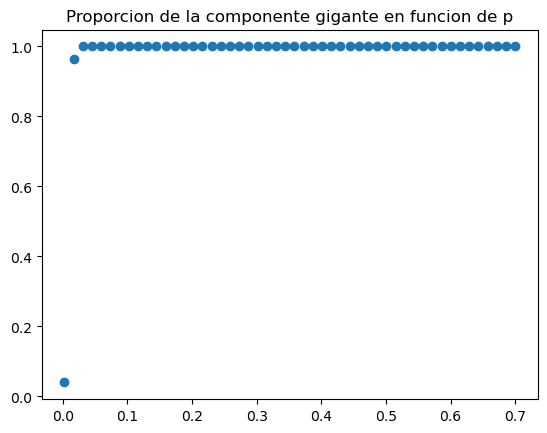

In [39]:
plt.scatter(p, S)
plt.title('Proporcion de la componente gigante en funcion de p')

Text(0.5, 1.0, 'Clustering en funcion de p')

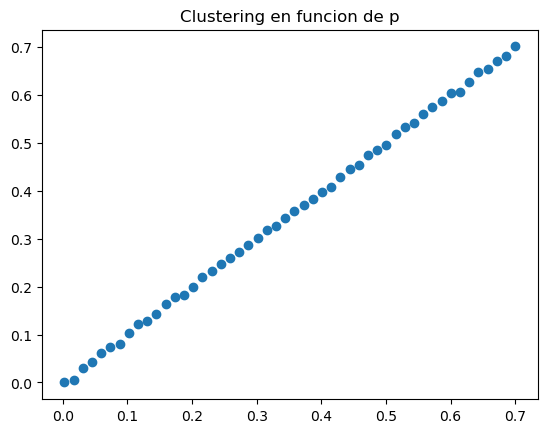

In [40]:

plt.scatter(p,k_arr)
plt.title('Clustering en funcion de p')

## Ejercicio 7. Conectividad total de la red

Fije  N=100 y considere valores de  
p cercanos a logN/N.
 

Calcule el valor aproximado de  logN/N.

Elija varios valores de  p por debajo y por encima de ese umbral.
      
Para cada valor de  p, genere varias realizaciones del grafo.

Determine en cada caso si el grafo es conexo o no.
    
Estime la proporción de grafos conexos para cada valor de  p.

Grafique esa proporción en función de  p.

Pregunta conceptual.
¿Cuál es la diferencia entre que exista una componente gigante y que toda la red sea conexa?

que el que tenga una componente gigante no implica que sea conexa

In [41]:
N = 100
p = np.linspace(np.log(0.5*N)*N,np.log(1.5*N)/N,5)
logN = np.log(N)/N
print(logN)
proportion = []

for p1 in p:
    is_connected = []
    n = 300
    for i in range(0,n):
        g = nx.erdos_renyi_graph(N,p1)
        if nx.is_connected(g) == True:
            is_connected.append(1)
        else:
            is_connected.append(0)
        
    num_cc = sum(is_connected)
    proportion.append(num_cc/n)



    

0.04605170185988092


Text(0.5, 1.0, 'p vs la proporcion de la componente gigante')

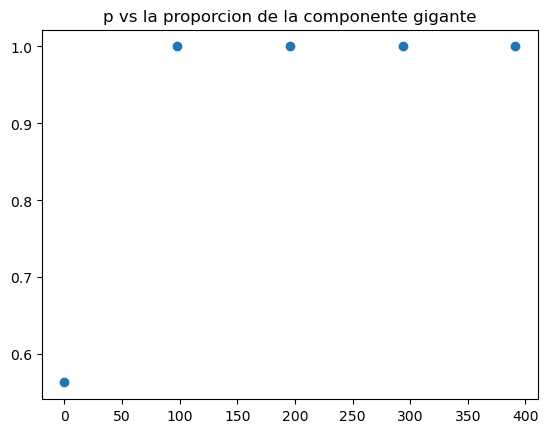

In [42]:
plt.scatter(p,proportion)
plt.title('p vs la proporcion de la componente gigante')

# 3.1.5 Ejercicios: efecto de mundo pequeño
Networkx tiene la función watts_strogatz_graph(N, k, p), donde  
N
  son la cantidad de vértices,  
k
  con cuantos vecinos más cercanos se conecta cada vértice y  
p
  la probabilidad. Deberán usar esa gráfica en algunos de los siguientes ejercicios.

## Ejercicio 1. Red regular y distancias

Considere una red regular en anillo con  N=100  nodos, donde cada nodo está conectado con sus  k=4  vecinos más cercanos.

Genere la red.

Dibuje la red obtenida.

Calcule el coeficiente de clustering promedio.

Calcule la longitud media de camino entre nodos.

Interprete los resultados.

Pregunta conceptual.
¿Cómo describiría la estructura local y global de esta red?
Respuesta: describiria la estructura global como una k-regular altamente conectada entre nodos, y de forma global la describiria como una red en la que se reduce bastante la distancia de un nodo a otro, teniendo una estructura de mundo pequeño.


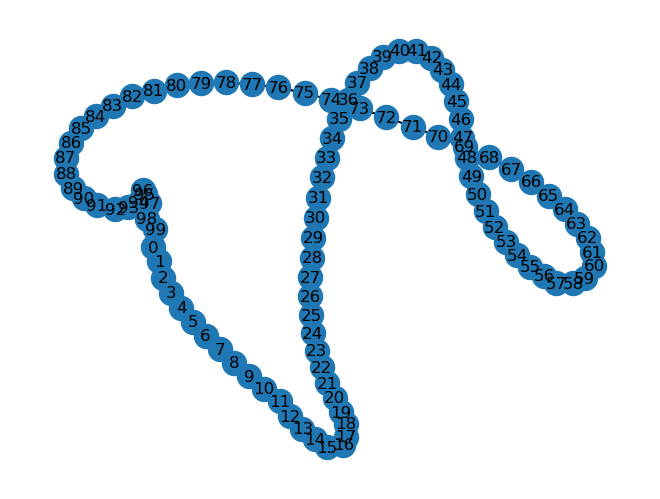

In [43]:
N = 100
k = 4
p = 0
G = nx.watts_strogatz_graph(N, k, p)
nx.draw(G, with_labels= True)

In [44]:
print('clustering promedio:',nx.average_clustering(G))
print('longitud media', nx.average_shortest_path_length(G))



clustering promedio: 0.5
longitud media 12.878787878787879


## Ejercicio 2. Efecto de reconectar algunas aristas

Considere redes de Watts–Strogatz con  
N=100 ,  k=4  y distintos valores de la probabilidad de reconexión β=0,0.01,0.05,0.1,0.5,1.
 

Para cada valor de  β:

Genere una realización de la red.

Calcule el coeficiente de clustering promedio.

Calcule la longitud media de camino.

Organice los resultados en una tabla.

Pregunta conceptual.

¿Cómo cambian el clustering y la longitud media de camino al aumentar  β? El clustering baja al igual que la longitud media entre nodos



In [45]:
N = 100
k = 4
p = [0,0.01,0.05,0.1,0.5,1]
G = [nx.watts_strogatz_graph(N,k,i) for i in p]

clus = []
average = []
for g in G:
    clus.append(nx.average_clustering(g))
    average.append(nx.average_shortest_path_length(g))

[0.5, 0.484, 0.39266666666666666, 0.3963333333333333, 0.11028571428571428, 0.02195238095238095]
[12.878787878787879, 9.153535353535354, 6.033131313131313, 5.250909090909091, 3.6294949494949496, 3.449090909090909]


Text(0, 0.5, 'Longitud promedio')

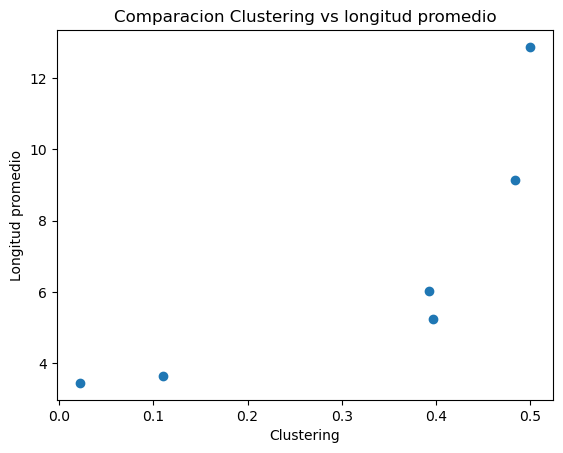

In [46]:
#Graficas y array del clustering promedio y el longitud promedio entre nodos
print(clus)
print(average)
plt.scatter(clus,average)
plt.title('Comparacion Clustering vs longitud promedio')
plt.xlabel('Clustering')
plt.ylabel('Longitud promedio')

Considere el modelo de Watts–Strogatz con  N=100 y  k=4.

Para varios valores de  β, calcule:
C(β),L(β).
 
Normalice estos valores respecto al caso regular  
β=0:
C(β)/C(0),L(β)/L(0).
 
Grafique ambas cantidades en función de β.
Identifique el rango de valores de β en el que la red presenta efecto de mundo pequeño.


Pregunta conceptual.
¿Por qué se dice que una red está en el régimen de mundo pequeño cuando la longitud media de camino disminuye mucho, pero el clustering permanece relativamente alto? Porque al tener un clustering alto se puede decir que la red esta altamente conectada entre ella y entonces esto acorta demasiado los caminos de un nodo a otro



In [47]:
#Defino mi red y mi ciclo for:
N = 100
k = 4
p = np.linspace(0,1,50)

G = [nx.watts_strogatz_graph(N,k,i) for i in p]
clus0 = nx.average_clustering(G[0])
l0 = nx.average_shortest_path_length(G[0])

clus_norm = []
l_norm = []
for g in G:
    clus = nx.average_clustering(g)/clus0
    l = nx.average_shortest_path_length(g)/l0

    l_norm.append(l)
    clus_norm.append(clus)

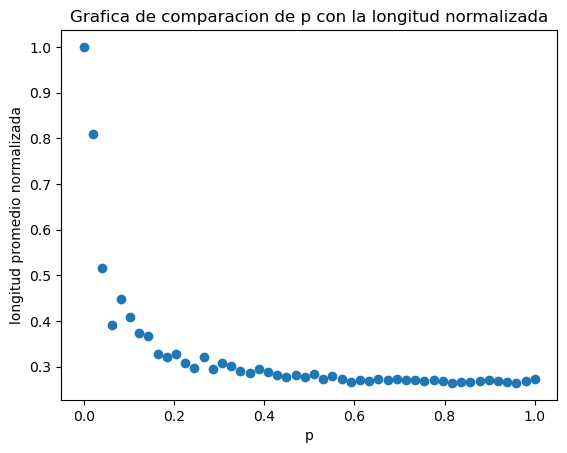

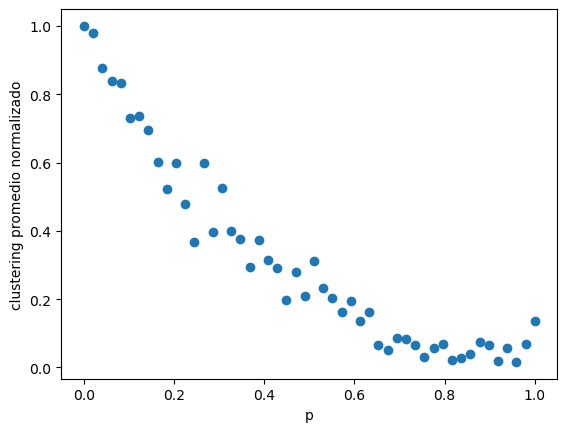

In [48]:
#Grafica de comparacion de p con la longitud normalizada
plt.scatter(p,l_norm)
plt.title('Grafica de comparacion de p con la longitud normalizada')
plt.xlabel('p')
plt.ylabel('longitud promedio normalizada')
plt.show()
#Grafica de comparacion de p con el clustering normalizado
plt.scatter(p,clus_norm)
plt.xlabel('p')
plt.ylabel('clustering promedio normalizado')
plt.show()

## Ejercicio 4. Comparación entre Watts–Strogatz y Erdős–Rényi

Considere una red de Watts–Strogatz con  N=100,  k=4 y un valor pequeño de β , y compárela con una red de Erdős–Rényi con número de nodos similar y grado promedio comparable.

Genere ambas redes.

Calcule en cada caso:

el coeficiente de clustering promedio,

la longitud media de camino.

Dibuje ambas redes.

Compare los resultados.

Pregunta conceptual.

¿Por qué una red de Watts–Strogatz puede presentar efecto de mundo pequeño de forma más clara que una red de Erdős–Rényi? porque la red de watts-strogatz ya tiene por definicion el numero de vecinos que debe de tener una red.

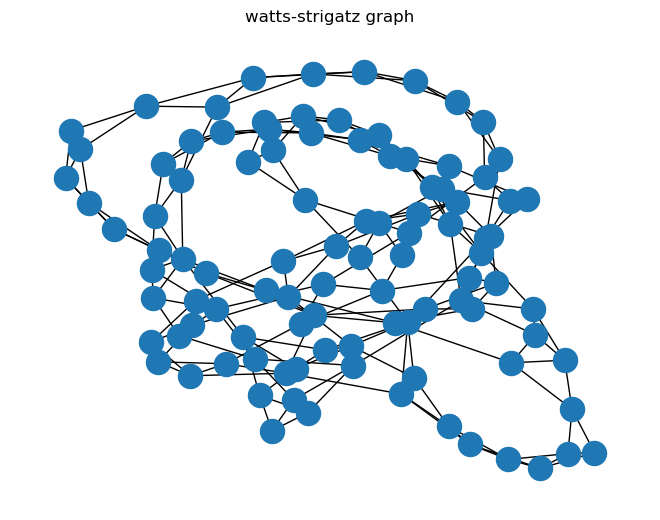

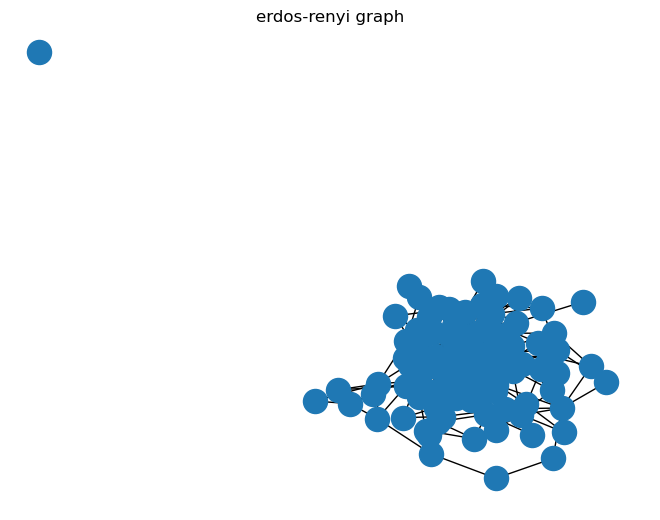

In [49]:
#Compara una watts-strogatz con una erdos renyi con la esperanza de gradon promedio mas o menos igual
N=100
k = 4
p = 0.05

g1 = nx.watts_strogatz_graph(N,k,p)
prom = 2 *nx.number_of_edges(g1)/nx.number_of_nodes(g1)
g2 = nx.erdos_renyi_graph(100,prom/99)
nx.draw(g1)
plt.title('watts-strigatz graph')
plt.show()
nx.draw(g2)
plt.title('erdos-renyi graph')
plt.show()

In [50]:

print('clustering de watts-strogatz',nx.average_clustering(g1))
print('clustering de erdos-renyi',nx.average_clustering(g2))

clustering de watts-strogatz 0.423
clustering de erdos-renyi 0.05838095238095238


In [51]:
print('longitud promedio watts-strogatz:',nx.average_shortest_path_length(g1))
max_cc =max(nx.connected_components(g2), key=len)
sub = g2.subgraph(max_cc)
print('longitud promedio erdos-renyi:',nx.average_shortest_path_length(sub))

longitud promedio watts-strogatz: 5.348080808080808
longitud promedio erdos-renyi: 3.04040404040404
